In [6]:
import pandas as pd
import numpy as np
import nltk


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
df = pd.read_csv("AllProductReviews.csv")
df

,ReviewTitle,ReviewBody,ReviewStar,Product
0,Honest review of an edm music lover\n,No doubt it has a great bass and to a great ex...,3,boAt Rockerz 255
1,Unreliable earphones with high cost\n,"This earphones are unreliable, i bought it be...",1,boAt Rockerz 255
2,Really good and durable.\n,"i bought itfor 999,I purchased it second time,...",4,boAt Rockerz 255
3,stopped working in just 14 days\n,Its sound quality is adorable. overall it was ...,1,boAt Rockerz 255
4,Just Awesome Wireless Headphone under 1000...😉\n,Its Awesome... Good sound quality & 8-9 hrs ba...,5,boAt Rockerz 255
...,...,...,...,...
14332,Good\n,Good\n,4,JBL T110BT
14333,Amazing Product\n,An amazing product but a bit costly.\n,5,JBL T110BT
14334,Not bad\n,Sound\n,1,JBL T110BT
14335,a good product\n,the sound is good battery life is good but the...,5,JBL T110BT


In [10]:
print(df.head())

                                        ReviewTitle  \
0             Honest review of an edm music lover\n   
1             Unreliable earphones with high cost\n   
2                        Really good and durable.\n   
3                 stopped working in just 14 days\n   
4  Just Awesome Wireless Headphone under 1000...😉\n   

                                          ReviewBody  ReviewStar  \
0  No doubt it has a great bass and to a great ex...           3   
1  This  earphones are unreliable, i bought it be...           1   
2  i bought itfor 999,I purchased it second time,...           4   
3  Its sound quality is adorable. overall it was ...           1   
4  Its Awesome... Good sound quality & 8-9 hrs ba...           5   

            Product  
0  boAt Rockerz 255  
1  boAt Rockerz 255  
2  boAt Rockerz 255  
3  boAt Rockerz 255  
4  boAt Rockerz 255  


In [11]:
print(df.columns)

Index(['ReviewTitle', 'ReviewBody', 'ReviewStar', 'Product'], dtype='object')


In [12]:
df['review']= df['ReviewTitle'] + " " + df['ReviewBody']
df

,ReviewTitle,ReviewBody,ReviewStar,Product,review
0,Honest review of an edm music lover\n,No doubt it has a great bass and to a great ex...,3,boAt Rockerz 255,Honest review of an edm music lover\n No doubt...
1,Unreliable earphones with high cost\n,"This earphones are unreliable, i bought it be...",1,boAt Rockerz 255,Unreliable earphones with high cost\n This ea...
2,Really good and durable.\n,"i bought itfor 999,I purchased it second time,...",4,boAt Rockerz 255,"Really good and durable.\n i bought itfor 999,..."
3,stopped working in just 14 days\n,Its sound quality is adorable. overall it was ...,1,boAt Rockerz 255,stopped working in just 14 days\n Its sound qu...
4,Just Awesome Wireless Headphone under 1000...😉\n,Its Awesome... Good sound quality & 8-9 hrs ba...,5,boAt Rockerz 255,Just Awesome Wireless Headphone under 1000...😉...
...,...,...,...,...,...
14332,Good\n,Good\n,4,JBL T110BT,Good\n Good\n
14333,Amazing Product\n,An amazing product but a bit costly.\n,5,JBL T110BT,Amazing Product\n An amazing product but a bit...
14334,Not bad\n,Sound\n,1,JBL T110BT,Not bad\n Sound\n
14335,a good product\n,the sound is good battery life is good but the...,5,JBL T110BT,a good product\n the sound is good battery lif...


In [13]:
def convert_sentiment(star):
  if star <= 2:
    return 0
  elif star == 3:
    return 2
  else:
    return 1

df['sentiment'] = df['ReviewStar'].apply(convert_sentiment)

In [14]:
df = df[['review', 'sentiment']]
df.head()

,review,sentiment
0,Honest review of an edm music lover\n No doubt...,2
1,Unreliable earphones with high cost\n This ea...,0
2,"Really good and durable.\n i bought itfor 999,...",1
3,stopped working in just 14 days\n Its sound qu...,0
4,Just Awesome Wireless Headphone under 1000...😉...,1


In [15]:
import re
from nltk.corpus import stopwords

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'[^a-zA-Z]',' ',text)
  words = text.split()
  words = [w for w in words if w not in stop_words]
  return " ".join(words)

In [19]:
df.loc[:,'clean_review'] = df['review'].apply(clean_text)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_review']).toarray()

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer(max_features=5000)

In [23]:
from sklearn.model_selection import train_test_split
y = df['sentiment']

X_train , X_test, y_train , y_test = train_test_split(X_tfidf, y , test_size = 0.2, random_state=42)

In [43]:
from sklearn.linear_model import LogisticRegression
#model logistic regression
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)
y_pred_lr = model_lr.predict(X_test)


In [26]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

In [47]:
from sklearn.metrics import classification_report , confusion_matrix

print("Logistic regression results: ")
print(classification_report(y_test,y_pred_lr))

print("Confusion matrix: ")
print(confusion_matrix(y_test,y_pred_lr))

Logistic regression results: 
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       711
           1       0.93      0.81      0.86      1853
           2       0.28      0.49      0.36       304

    accuracy                           0.76      2868
   macro avg       0.65      0.69      0.66      2868
weighted avg       0.82      0.76      0.78      2868

Confusion matrix: 
[[ 544   41  126]
 [ 101 1499  253]
 [  76   78  150]]


In [46]:
print("Naive Bayes model results: ")
print(classification_report(y_test,y_pred_nb))

print("Confusion matrix: ")
print(confusion_matrix(y_test,y_pred_nb))

Naive Bayes model results: 
              precision    recall  f1-score   support

           0       0.84      0.62      0.72       711
           1       0.78      0.98      0.87      1853
           2       1.00      0.00      0.01       304

    accuracy                           0.79      2868
   macro avg       0.87      0.54      0.53      2868
weighted avg       0.82      0.79      0.74      2868

Confusion matrix: 
[[ 441  270    0]
 [  32 1821    0]
 [  49  254    1]]


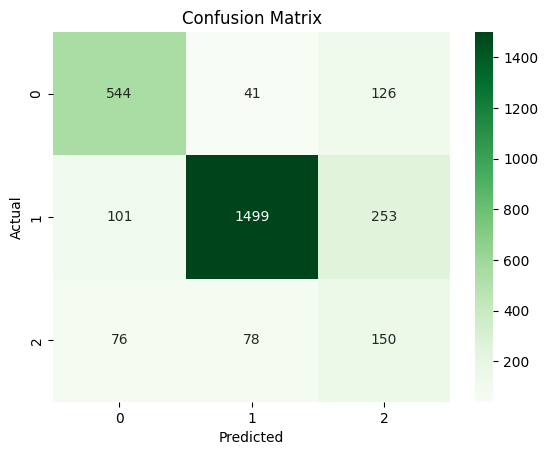

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred_lr)

sns.heatmap(cm, annot=True,fmt='d', cmap = 'Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

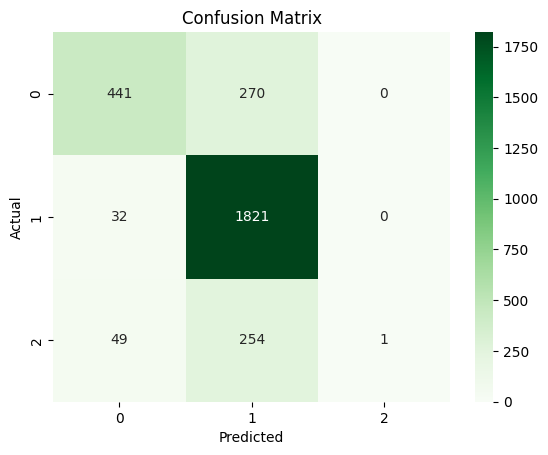

In [49]:
cm = confusion_matrix(y_test,y_pred_nb)

sns.heatmap(cm, annot=True,fmt='d', cmap = 'Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
df['sentiment'].value_counts()

,count
sentiment,
1,9402
0,3432
2,1503
